In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv("dataset\Twcs.csv")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2811774 entries, 0 to 2811773
Data columns (total 7 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   tweet_id                 int64  
 1   author_id                object 
 2   inbound                  bool   
 3   created_at               object 
 4   text                     object 
 5   response_tweet_id        object 
 6   in_response_to_tweet_id  float64
dtypes: bool(1), float64(1), int64(1), object(4)
memory usage: 131.4+ MB


In [ ]:
data.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [ ]:
data = data[data['inbound']==True]
data.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0
6,8,115712,True,Tue Oct 31 21:45:10 +0000 2017,@sprintcare is the worst customer service,"9,6,10",NaN
8,12,115713,True,Tue Oct 31 22:04:47 +0000 2017,@sprintcare You gonna magically change your co...,"11,13,14",15.0


In [ ]:
data = data.sample(n=20000,random_state=42)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 26861 to 1784436
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   tweet_id                 20000 non-null  int64  
 1   author_id                20000 non-null  object 
 2   inbound                  20000 non-null  bool   
 3   created_at               20000 non-null  object 
 4   text                     20000 non-null  object 
 5   response_tweet_id        17050 non-null  object 
 6   in_response_to_tweet_id  9718 non-null   float64
dtypes: bool(1), float64(1), int64(1), object(4)
memory usage: 1.1+ MB


In [ ]:
data = data.reset_index(drop=True)

In [ ]:
data = data['text']

## Text Preprocessing

In [ ]:
import re
import string

In [ ]:
def clean(text):
    text1 = re.sub(r"^@\w+",' ',text)
    text1 = re.sub(r'[#?.,$@]', ' ', text1)
    text1 = re.sub(r'\d+', ' ', text1)
    text1 = re.sub(r'\s+', ' ', text1).strip()
    text1 = re.sub(r'https?://\S+', ' ', text1)

    return text1


In [ ]:
text_list = data.tolist()
text_list[:5]

['@AppleSupport Basically for a chat to be opened from call log, the message app should be opened/running in background. Otherwise, it takes twice.',
 '@AppleSupport iOS 11.02 and Watchos4.0: No icon for Twitter notifications. Restart of iphone/watch, notif. off/on does not help. What to do? https://t.co/Jd98V9OvIu',
 'Dear god not again,@AppleSupport https://t.co/5Zf0Mnd6SI',
 '@ATVIAssist Hi there! If I buy Call of Duty WWII on steam today, do I have instant access to the open beta multiplayer?',
 "Hi @Safaricom_Care why can't I pay my my Dstv texts says the Org is unavailable"]

In [ ]:
clean_text = [clean(text) for text in text_list if len(text)>=3]

In [ ]:
clean_text[:5]

['Basically for a chat to be opened from call log the message app should be opened/running in background Otherwise it takes twice',
 'iOS and Watchos : No icon for Twitter notifications Restart of iphone/watch notif off/on does not help What to do   co/Jd V OvIu',
 'Dear god not again AppleSupport   co/ Zf Mnd SI',
 'Hi there! If I buy Call of Duty WWII on steam today do I have instant access to the open beta multiplayer',
 "Hi Safaricom_Care why can't I pay my my Dstv texts says the Org is unavailable"]

In [ ]:
!pip install langid

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 50.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langid: filename=langid-1.1.6-py3-none-any.whl size=1941171 sha256=a94c884c4ea93968e95e865deba4de053e5c41561621da441e932c44129f77dd
  Stored in directory: /root/.cache/pip/wheels/3c/bc/9d/266e27289b9019680d65d9b608c37bff1eff565b001c977ec5
Successfully built langid


In [ ]:
import langid

def is_english(text):

    lang, score = langid.classify(text)

    return lang == 'en'

In [ ]:
clean_text = [text for text in clean_text if is_english(text)]

## BERT

In [ ]:
!pip install sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
embeddings = model.encode(
    clean_text,
    batch_size=32,
    show_progress_bar=True
)

Batches:   0%|          | 0/577 [00:00<?, ?it/s]

In [ ]:
embeddings.shape

(18457, 384)

In [ ]:
from sklearn.preprocessing import normalize

X = normalize(embeddings)

## HDBSCAN

In [ ]:
!pip install hdbscan

In [ ]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    metric='euclidean'
)

labels = clusterer.fit_predict(X)

In [ ]:
from sklearn.metrics import davies_bouldin_score

mask = labels != -1

print(
    davies_bouldin_score(
        X[mask],
        labels[mask]
    )
)

1.6062465762136673


## KMeans

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [ ]:
k_range = range(2,15)

inertia=[]
sil_score = []

for k in k_range:
    km = KMeans(n_clusters=k,init='k-means++',random_state=42)
    km.fit_predict(X)

    inertia.append(km.inertia_)
    sil_score.append(silhouette_score(X,km.labels_))

Text(0, 0.5, 'Inertia')

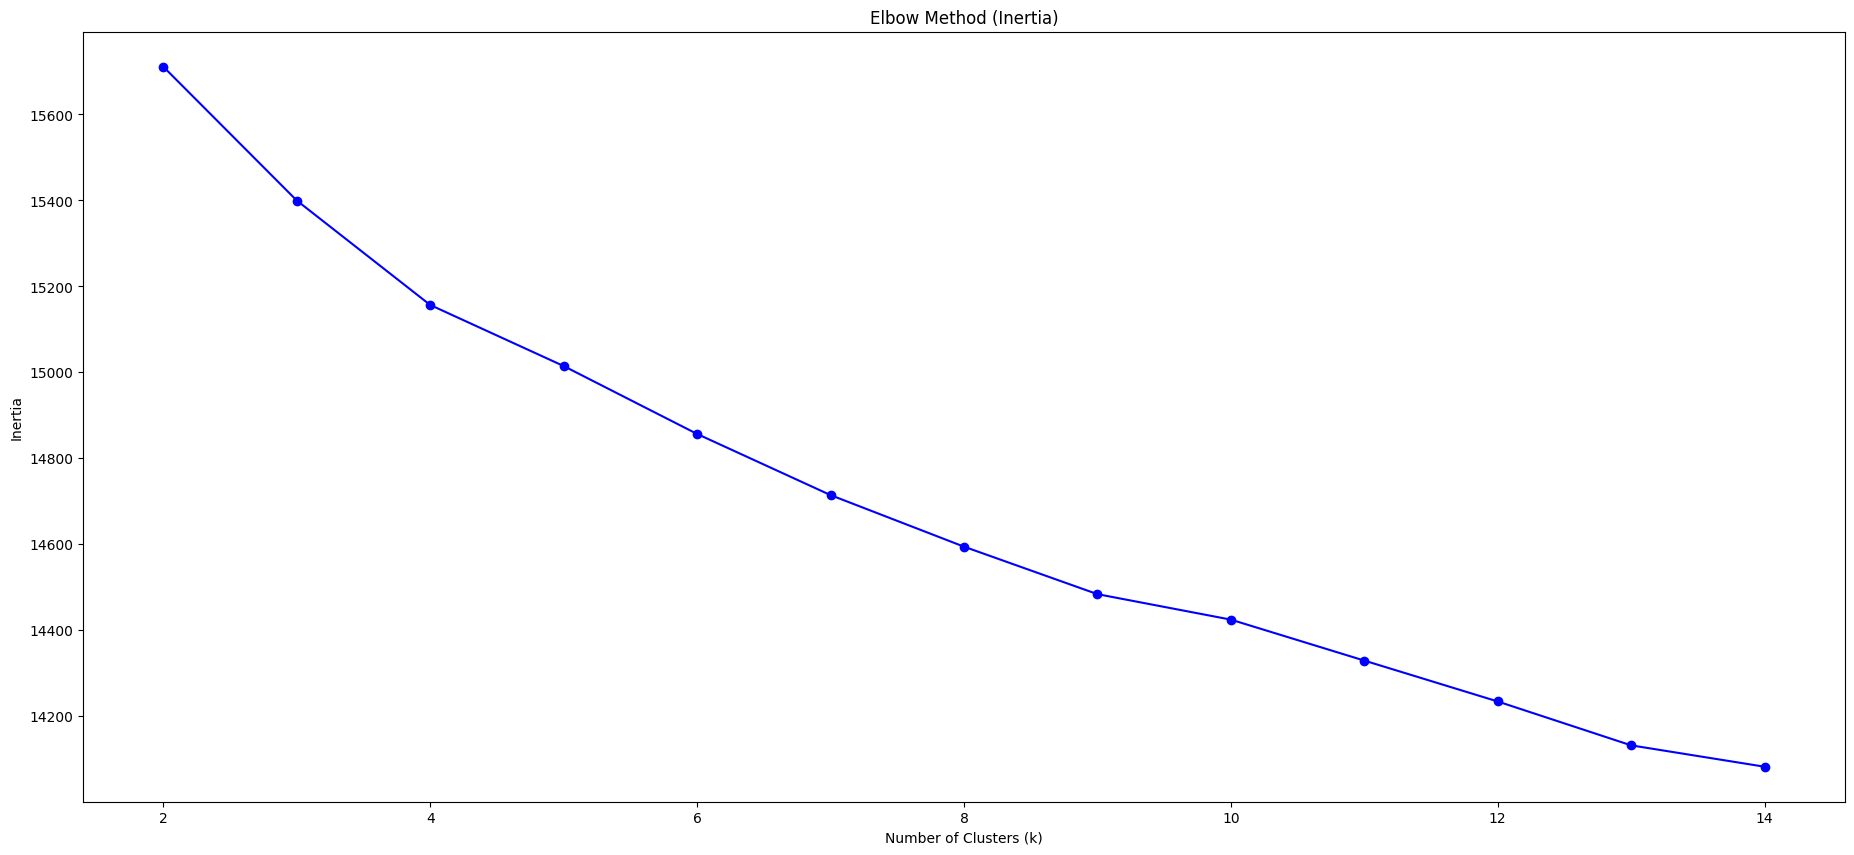

In [ ]:
plt.figure(figsize=(50, 10))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o', color='b')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

In [ ]:
cluster = 2
for score in sil_score:
    print(cluster,score)
    cluster+=1

2 0.02985554
3 0.022975223
4 0.02517945
5 0.022457851
6 0.024381893
7 0.024367355
8 0.025394212
9 0.02705769
10 0.02752393
11 0.026054211
12 0.028948382
13 0.029371575
14 0.029946012


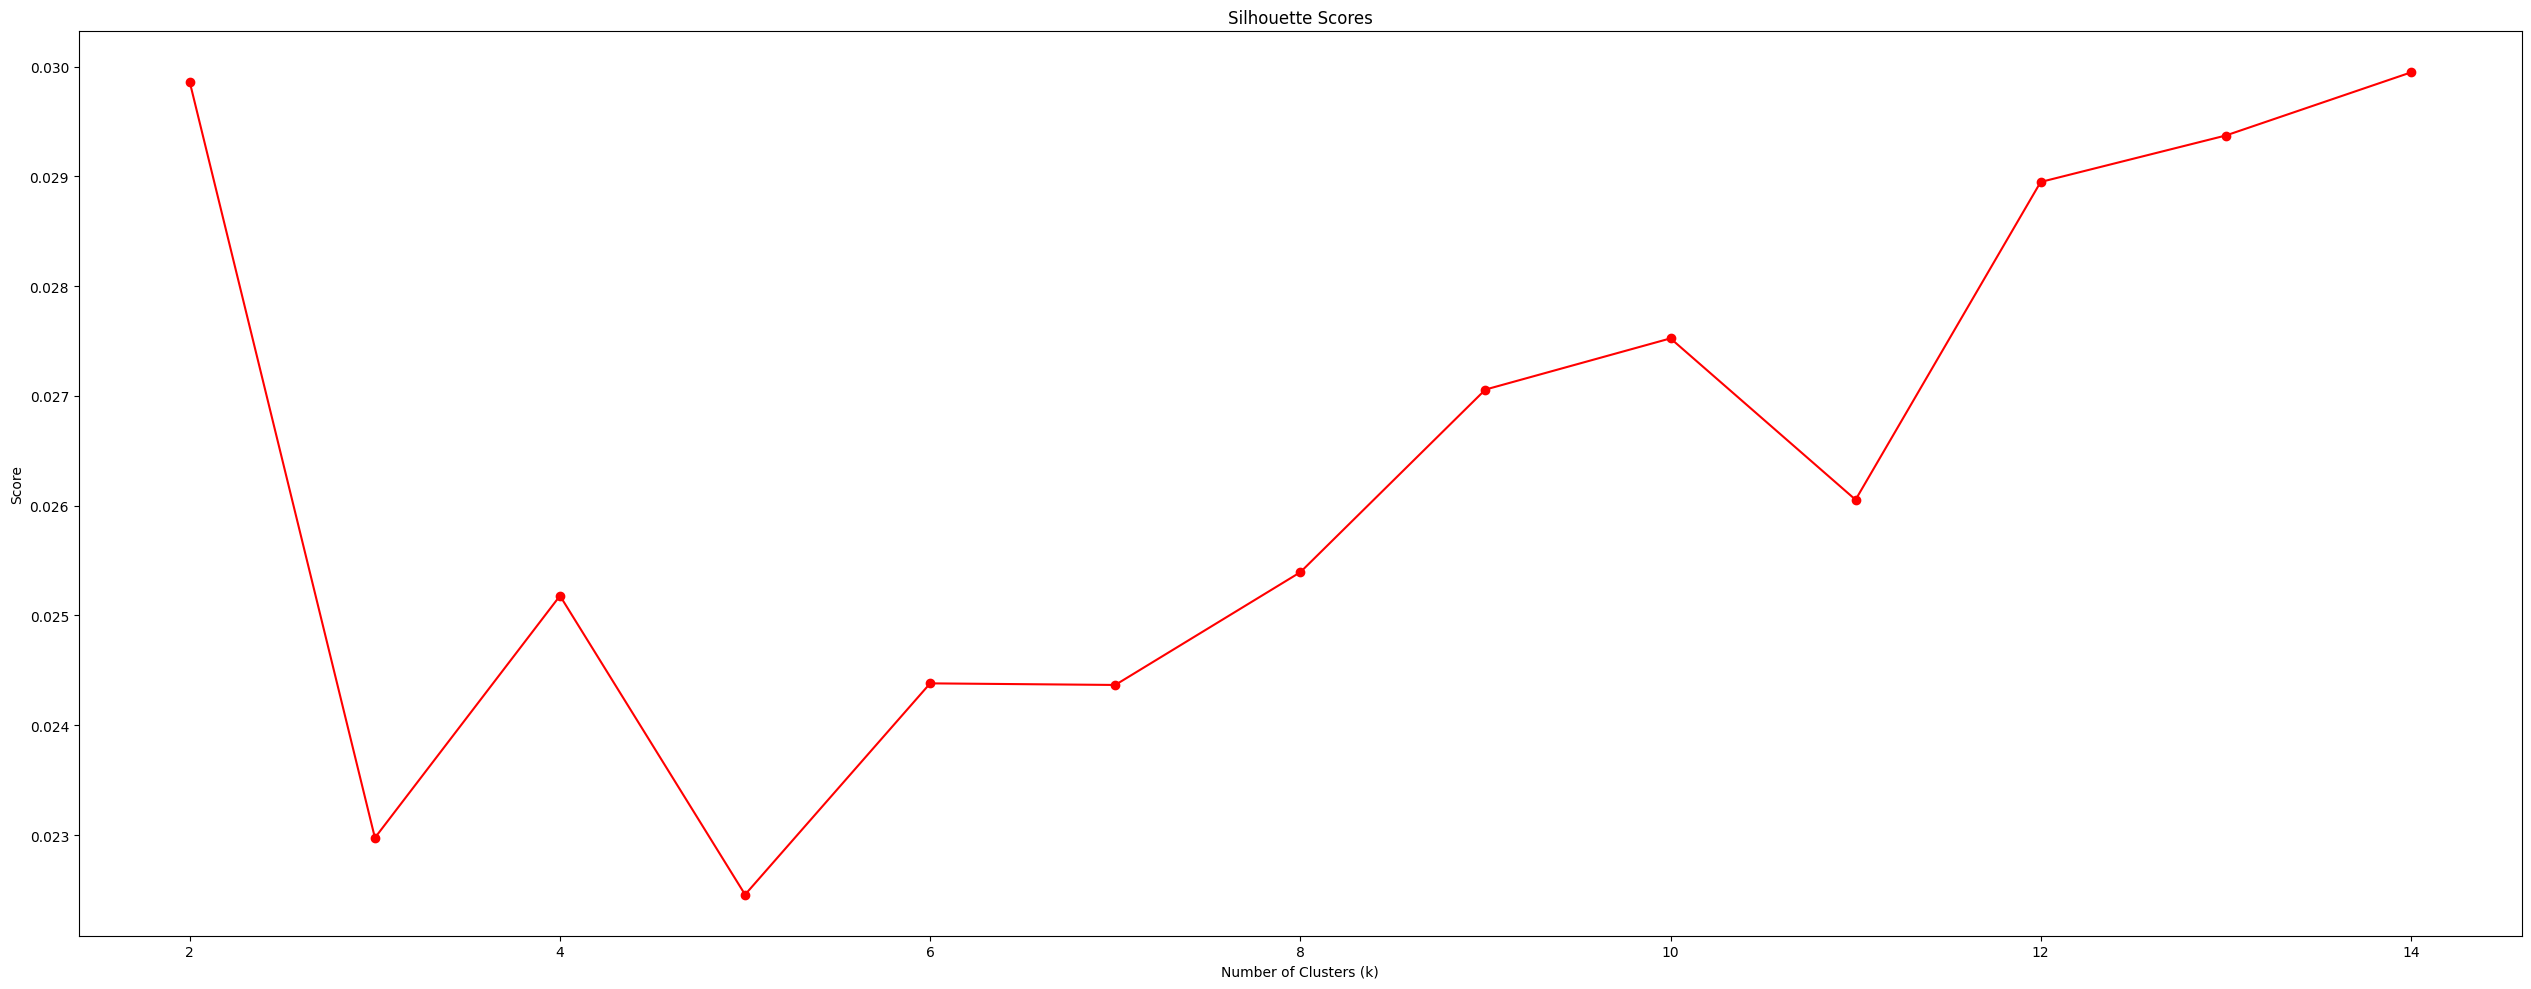

In [ ]:
plt.figure(figsize=(50, 10))
plt.subplot(1, 2, 2)
plt.plot(k_range, sil_score, marker='o', color='red')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

In [ ]:
k=10
km = KMeans(n_clusters=k,init='k-means++',random_state=42)
km.fit_predict(X)

array([2, 4, 6, ..., 7, 1, 5], dtype=int32)

In [ ]:
df = pd.DataFrame({
    "text": clean_text,
    "cluster": km.labels_
})

In [ ]:
df.head()

,text,cluster
0,Basically for a chat to be opened from call lo...,2
1,iOS and Watchos : No icon for Twitter notifica...,4
2,Dear god not again AppleSupport co/ Zf Mnd SI,6
3,Hi there! If I buy Call of Duty WWII on steam ...,8
4,Hi Safaricom_Care why can't I pay my my Dstv t...,2


In [ ]:
km_mask = labels != -1

print(
    davies_bouldin_score(
        X[km_mask],
        km.labels_[km_mask]
    )
)

2.30805692004983


In [ ]:
for i in range(k):
    print(f"\nCLUSTER {i}")

    cluster_samples = df[df["cluster"] == i]["text"].head(10)

    for text in cluster_samples:
        print(text)


CLUSTER 0
I realise that I've lived here for many years I've tolerated the enormous daily hassle of the redevelopment But no thought has been given to handling rugby crowds It's unacceptable and unsafe
great conductor working c very informative and well with regards with handling a delay and informing everybody travelling
Currently booked on DL DL
No trains from Blake St since !! Cancelled due to no drivers!! just on train now Uni at am Missed lecture! refund
And there is was no reschedule from my side You guys did yourself
Nice of you to pin blame on someone else I think you’ll find passengers don’t care who’s fault you think it is and would rather you worked together to fix it
Great excuse "The feedback alleged you made inappropriate or derogatory comments towards your driver " I did not Oh and fuck you
From where Hardly anyone got off it at TWY
Asked my driver nicely to switch from right wing talk radio to music He declined This is a fun ride
what's the sitch with delay repay if I 

## Visualization

In [ ]:
from sklearn.manifold import TSNE

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_2d = tsne.fit_transform(X)

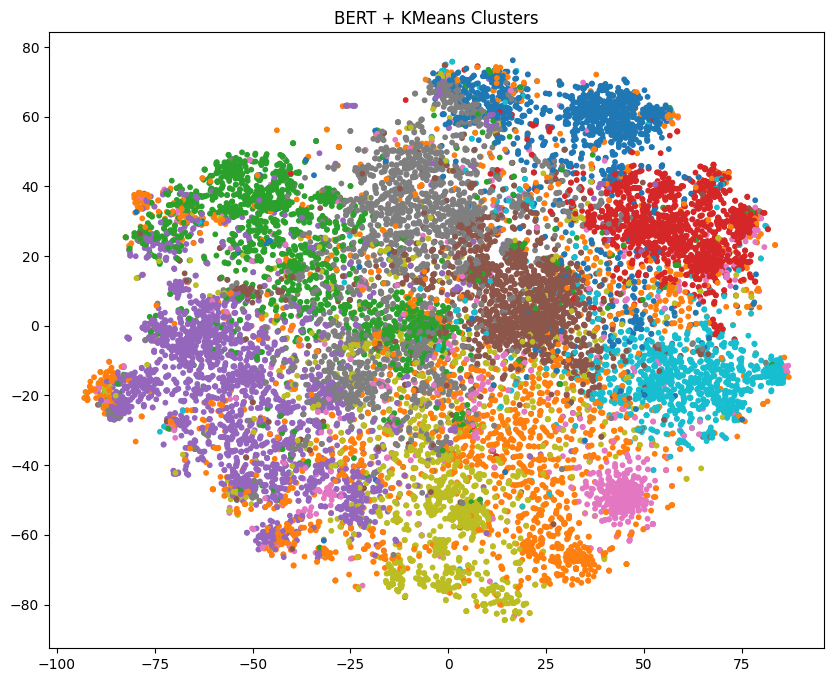

In [ ]:
plt.figure(figsize=(10,8))

plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=km.labels_,
    cmap='tab10',
    s=10
)

plt.title("BERT + KMeans Clusters")
plt.show()

In [ ]:
hdbscan.labels_

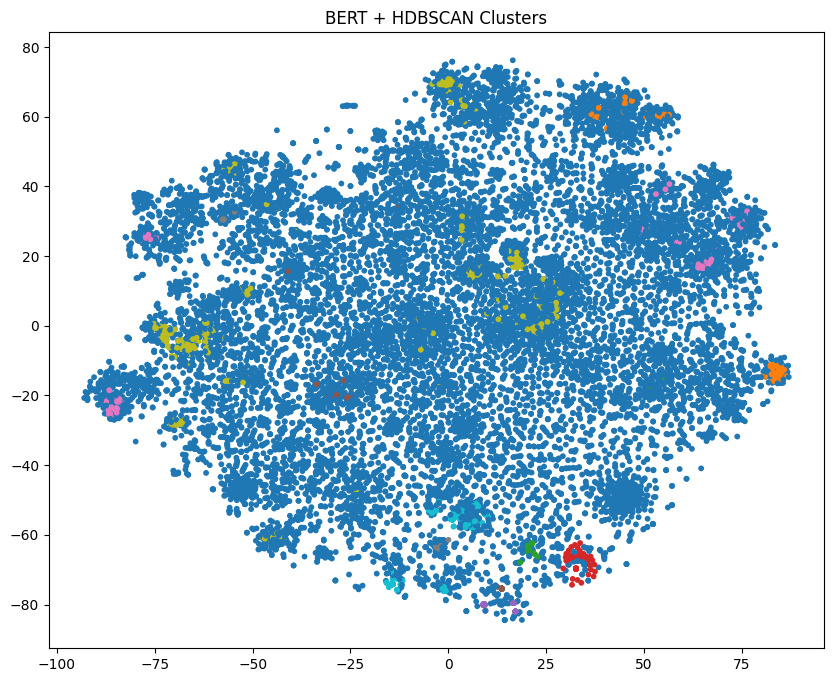

In [ ]:
plt.figure(figsize=(10,8))

plt.scatter(
    X_2d[:,0],
    X_2d[:,1],
    c=labels,
    cmap='tab10',
    s=10
)

plt.title("BERT + HDBSCAN Clusters")
plt.show()

In [ ]:
for cluster_id in sorted(df["cluster"].unique()):

    print(f"\n===== CLUSTER {cluster_id} =====")

    samples = df[df["cluster"] == cluster_id]["text"].head(10)

    for s in samples:
        print("-", s)


===== CLUSTER 0 =====
- I realise that I've lived here for many years I've tolerated the enormous daily hassle of the redevelopment But no thought has been given to handling rugby crowds It's unacceptable and unsafe
- great conductor working c very informative and well with regards with handling a delay and informing everybody travelling
- Currently booked on DL DL
- No trains from Blake St since !! Cancelled due to no drivers!! just on train now Uni at am Missed lecture! refund
- And there is was no reschedule from my side You guys did yourself
- Nice of you to pin blame on someone else I think you’ll find passengers don’t care who’s fault you think it is and would rather you worked together to fix it
- Great excuse "The feedback alleged you made inappropriate or derogatory comments towards your driver " I did not Oh and fuck you
- From where Hardly anyone got off it at TWY
- Asked my driver nicely to switch from right wing talk radio to music He declined This is a fun ride
- what's 

In [ ]:
cluster_names = {
    0: "Travel Delays",
    1: "Customer Feedback",
    2: "Network Outages",
    3: "Airline Support",
    4: "Tech Support",
    5: "Delivery Issues",
    6: "Digital Complaints",
    7: "Billing Issues",
    8: "Support Conversations",
    9: "Food & Grocery"
}

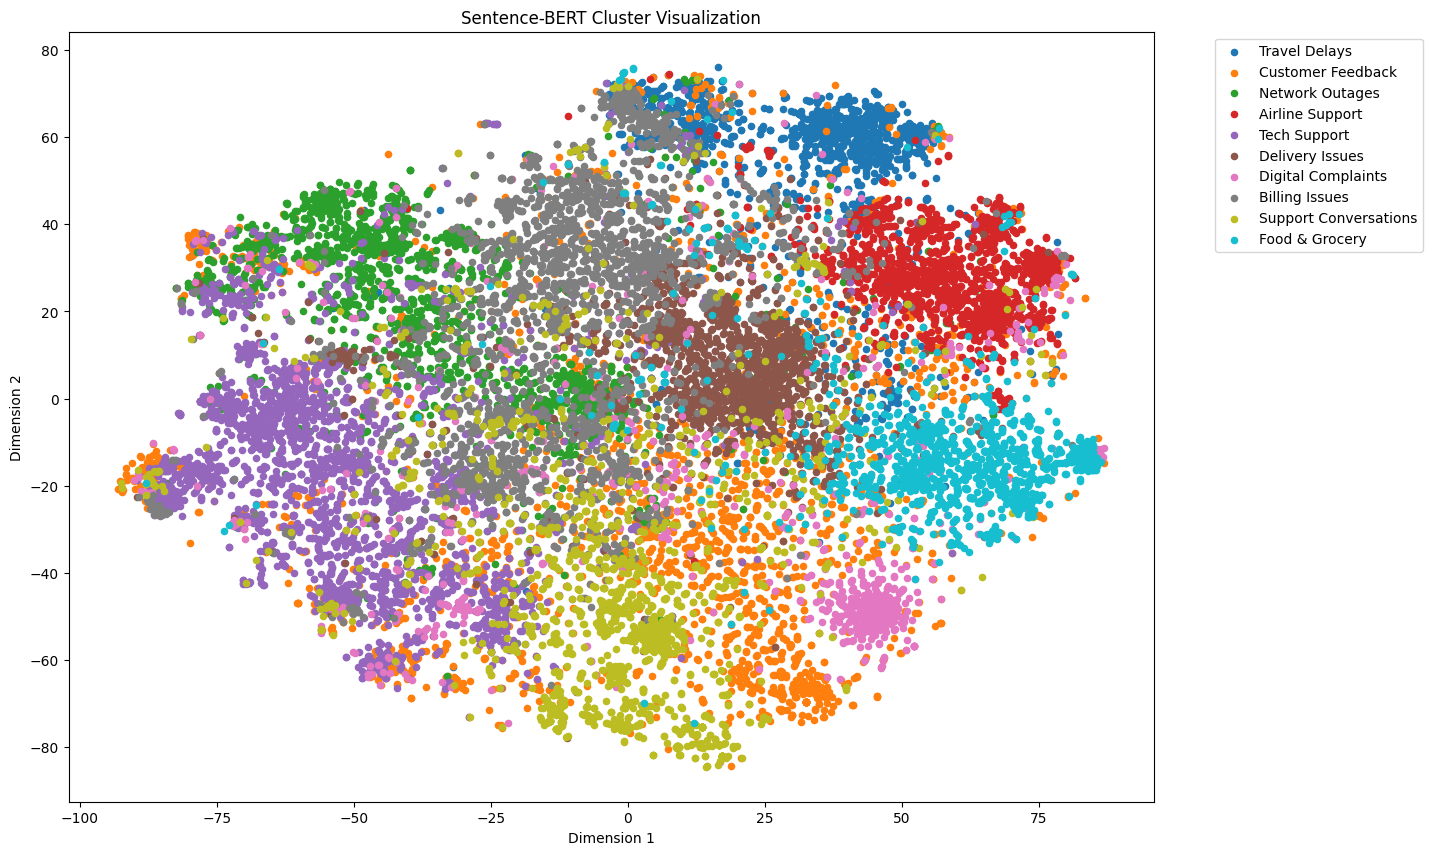

In [ ]:
plt.figure(figsize=(14,10))

for cluster_id in np.unique(km.labels_):

    indices = km.labels_ == cluster_id

    plt.scatter(
        X_2d[indices, 0],
        X_2d[indices, 1],
        label=cluster_names[cluster_id],
        s=20
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("Sentence-BERT Cluster Visualization")

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.show()